In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load Tanzania data
df = pd.read_csv('../data/tanzania.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [3]:
# Add country name
df['Country'] = 'Tanzania'
df = df.replace(-999, np.nan)

# Convert dates
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


In [4]:
# Remove duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Dropped {duplicates} duplicates")
else:
    print("No duplicates found.")

No duplicates found.


In [5]:
# Missing values report
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]
print("\nColumns with missing values:")
print(missing_report)


Columns with missing values:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


In [6]:
# Handle missing values using forward fill
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
for col in weather_cols:
    if col in df.columns:
        df[col] = df[col].ffill()

remaining = df[weather_cols].isna().sum().sum()
print(f"\nRemaining missing values after forward fill: {remaining}")


Remaining missing values after forward fill: 0


In [7]:
# Outlier detection
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
print("\nOutlier detection (|Z| > 3):")
for col in outlier_cols:
    if col in df.columns:
        clean_data = df[col].dropna()
        if len(clean_data) > 0:
            z_scores = np.abs(stats.zscore(clean_data))
            outliers = (z_scores > 3).sum()
            print(f"{col}: {outliers} outliers detected")
print("\nNote: Outliers retained as they may represent real extreme weather events")


Outlier detection (|Z| > 3):
T2M: 1 outliers detected
T2M_MAX: 2 outliers detected
T2M_MIN: 4 outliers detected
PRECTOTCORR: 81 outliers detected
RH2M: 2 outliers detected
WS2M: 8 outliers detected
WS2M_MAX: 4 outliers detected

Note: Outliers retained as they may represent real extreme weather events


In [8]:
# Export cleaned data
df.to_csv('../data/tanzania_clean.csv', index=False)
print("\nCleaned data saved to: data/tanzania_clean.csv")
print(f"Final shape: {df.shape}")


Cleaned data saved to: data/tanzania_clean.csv
Final shape: (4108, 16)


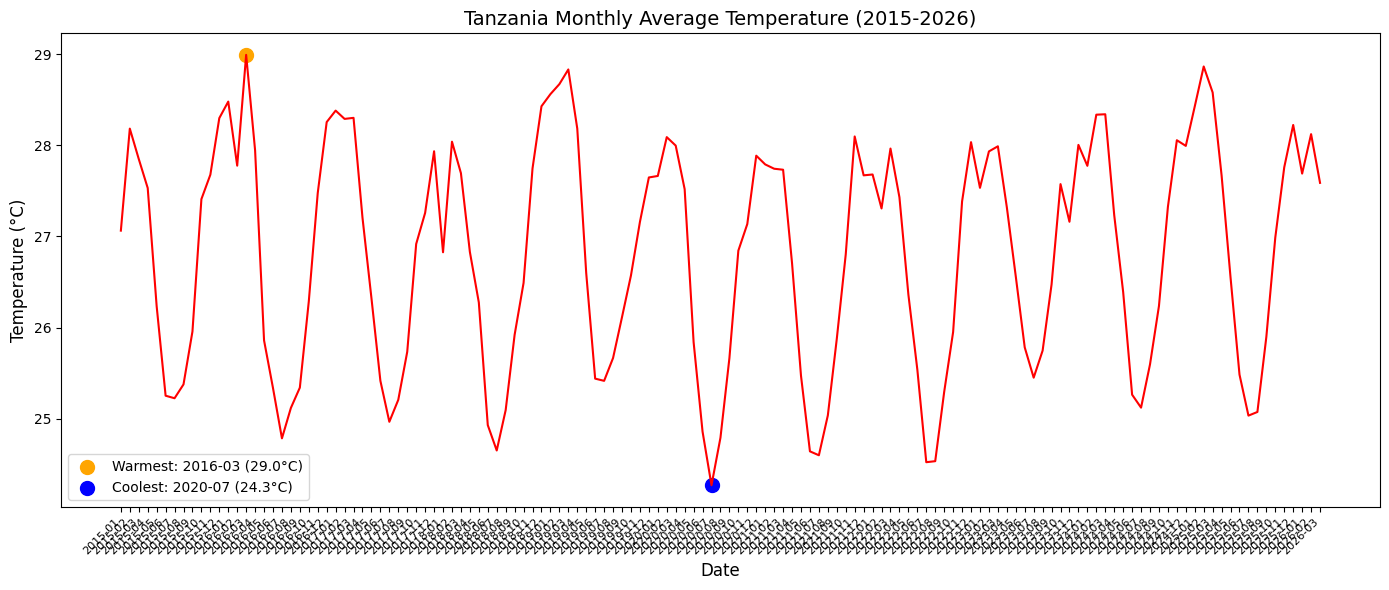

In [9]:
# Monthly average temperature time series
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_temp.index.astype(str), monthly_temp.values, linewidth=1.5, color='red')

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
plt.scatter(str(warmest), monthly_temp.max(), color='orange', s=100, label=f'Warmest: {warmest} ({monthly_temp.max():.1f}°C)')
plt.scatter(str(coolest), monthly_temp.min(), color='blue', s=100, label=f'Coolest: {coolest} ({monthly_temp.min():.1f}°C)')

plt.title('Tanzania Monthly Average Temperature (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

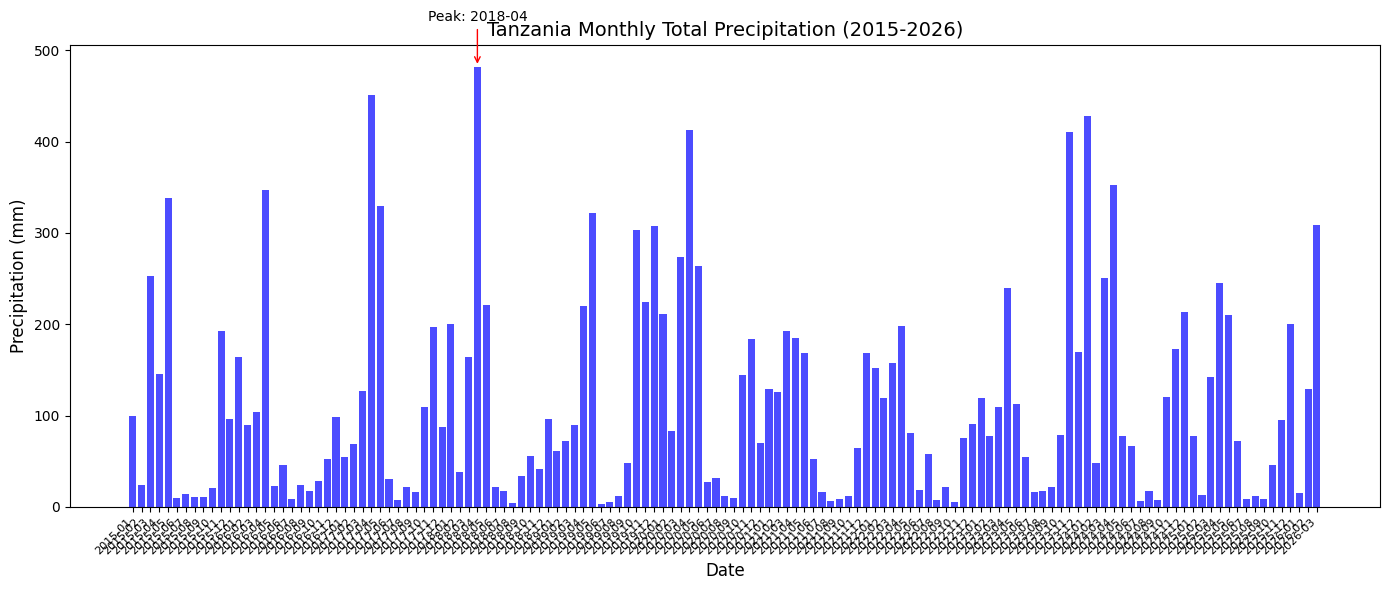

In [10]:
# Monthly total precipitation bar chart
monthly_precip = df.groupby(df['Date'].dt.to_period('M'))['PRECTOTCORR'].sum()

plt.figure(figsize=(14, 6))
plt.bar(monthly_precip.index.astype(str), monthly_precip.values, color='blue', alpha=0.7)

peak_month = monthly_precip.idxmax()
peak_value = monthly_precip.max()
plt.annotate(f'Peak: {peak_month}', xy=(str(peak_month), peak_value), 
             xytext=(str(peak_month), peak_value + 50),
             ha='center', fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Tanzania Monthly Total Precipitation (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


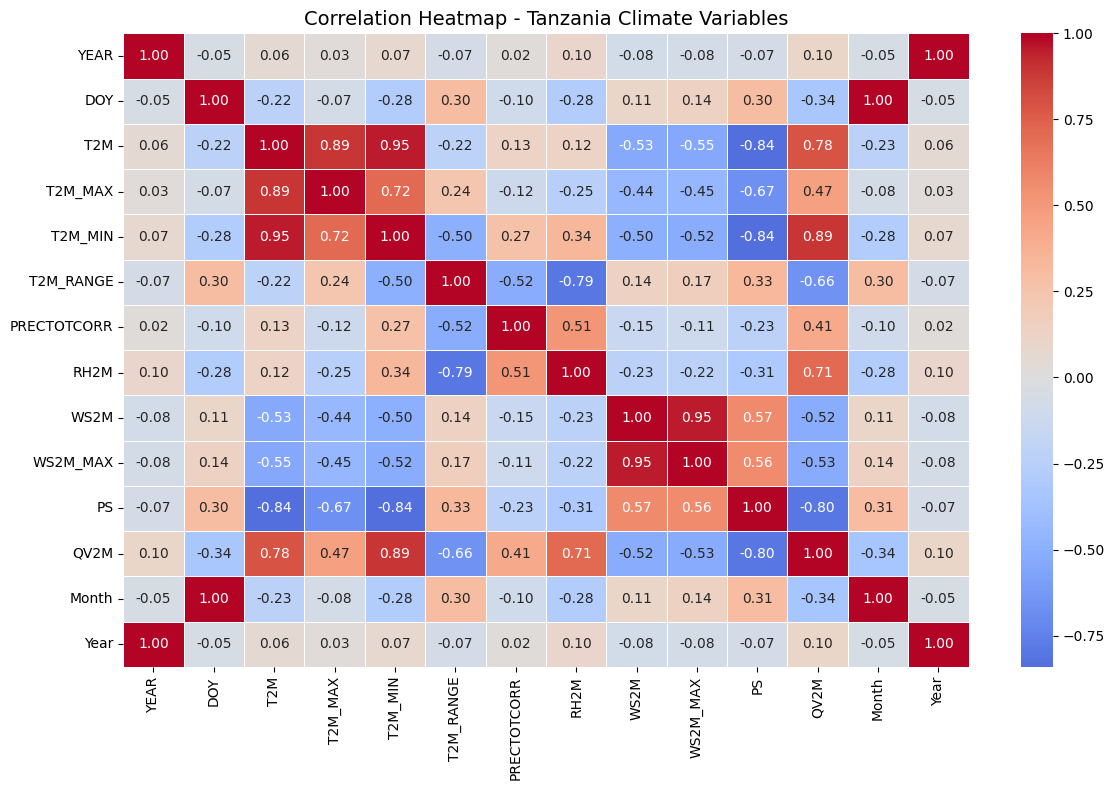

In [11]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Tanzania Climate Variables', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Top 3 strongest correlations
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corrs = upper.unstack().dropna().sort_values(ascending=False).head(3)
print("\nTop 3 strongest correlations:")
print(top_corrs)


Top 3 strongest correlations:
Year      YEAR    1.000000
Month     DOY     0.996557
WS2M_MAX  WS2M    0.951026
dtype: float64


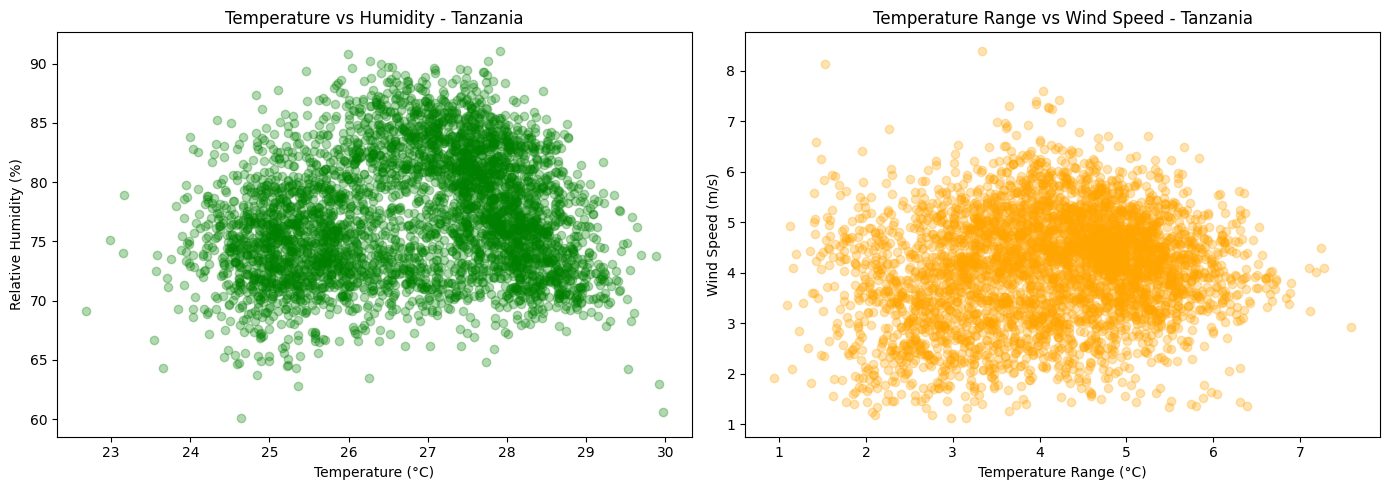

In [13]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, color='green')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Temperature vs Humidity - Tanzania')

axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='orange')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Temperature Range vs Wind Speed - Tanzania')

plt.tight_layout()
plt.show()

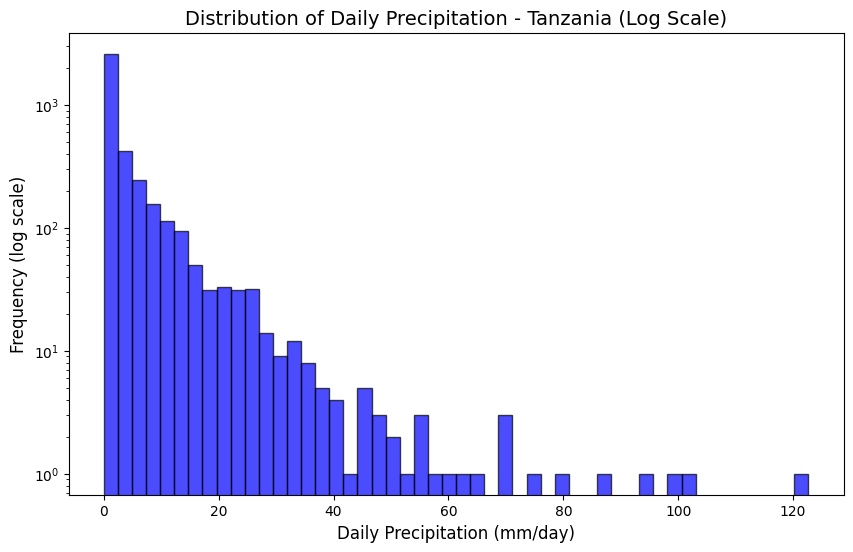


Most days have low precipitation (0-5 mm), with few extreme rainfall events
Tanzania EDA complete!


In [14]:
# Precipitation histogram (log scale)
plt.figure(figsize=(10, 6))
precip_data = df['PRECTOTCORR'].dropna()
precip_data = precip_data[precip_data > 0]

plt.hist(precip_data, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.yscale('log')
plt.xlabel('Daily Precipitation (mm/day)', fontsize=12)
plt.ylabel('Frequency (log scale)', fontsize=12)
plt.title('Distribution of Daily Precipitation - Tanzania (Log Scale)', fontsize=14)
plt.show()

print("\nMost days have low precipitation (0-5 mm), with few extreme rainfall events")
print("Tanzania EDA complete!")